# Setup

In [2]:
import numpy as np
import skfuzzy as fuzz
import matplotlib.pyplot as plt
# Configure matplotlib for better display
plt.rcParams['figure.figsize'] = [10, 5]
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Exercise 1.1: Crisp vs. Fuzzy Tallness Gen AI: don't help!
The slides show crisp and fuzzy sets for tallness. The universe of discourse for height ranges from 150 cm
to 210 cm.
In [ ]:
A X {0, 1}
fA(x) : X → {0, 1}, fA(x) = {
1 if x ∈ A
0 if x ∉ A
μA(x)
[0, 1]
μA(x) : X → [0, 1]  
Task: Plot a crisp set where "tall" means height ≥ 180 cm (Boolean boundary), and then plot a fuzzy
version where tallness is a gradual transition. Use the following triangular fuzzy sets:
Short: Triangle(150, 150, 175)
Average: Triangle(160, 175, 190)
Tall: Triangle(180, 200, 210)

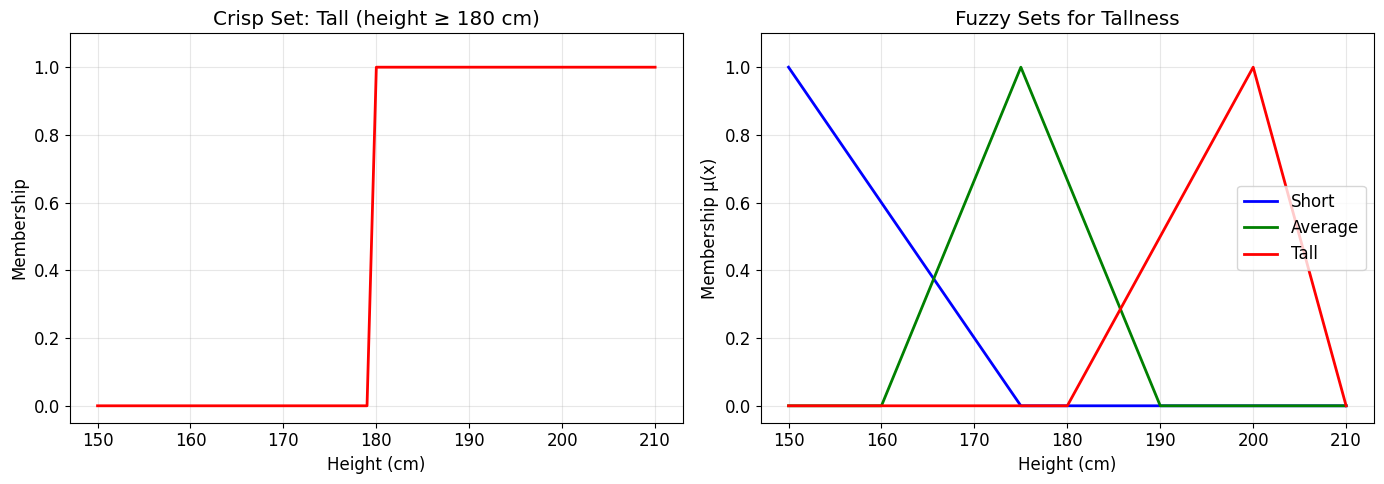

A person who is 184 cm tall:
 μ_average(184) = 0.40
 μ_tall(184) = 0.20
 → Partial membership in MULTIPLE sets simultaneously.


In [3]:
# Universe of discourse: height in cm
x_height = np.arange(150, 211, 1)

# --- Crisp set: tall if height >= 180 ---
crisp_tall = np.where(x_height >= 180, 1.0, 0.0)

# --- Fuzzy sets ---
short = fuzz.trimf(x_height, [150, 150, 175])
average = fuzz.trimf(x_height, [160, 175, 190])
tall = fuzz.trimf(x_height, [180, 200, 210])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Crisp
ax1.plot(x_height, crisp_tall, 'r-', linewidth=2)
ax1.set_title('Crisp Set: Tall (height ≥ 180 cm)')
ax1.set_xlabel('Height (cm)')
ax1.set_ylabel('Membership')
ax1.set_ylim(-0.05, 1.1)

# Fuzzy
ax2.plot(x_height, short, 'b-', linewidth=2, label='Short')
ax2.plot(x_height, average, 'g-', linewidth=2, label='Average')
ax2.plot(x_height, tall, 'r-', linewidth=2, label='Tall')
ax2.set_title('Fuzzy Sets for Tallness')
ax2.set_xlabel('Height (cm)')
ax2.set_ylabel('Membership μ(x)')
ax2.set_ylim(-0.05, 1.1)
ax2.legend()

plt.tight_layout()
plt.show()

# Demonstrate partial membership
height = 184
mu_avg = fuzz.interp_membership(x_height, average, height)
mu_tall = fuzz.interp_membership(x_height, tall, height)

print(f"A person who is {height} cm tall:")
print(f" μ_average({height}) = {mu_avg:.2f}")
print(f" μ_tall({height}) = {mu_tall:.2f}")
print(f" → Partial membership in MULTIPLE sets simultaneously.")


# Common Membership Functions
The shape of a membership function determines how elements map to degrees of membership. The
most common types are:
Type Parameters scikit-fuzzy function
Triangular (left foot), (peak), (right foot) fuzz.trimf(x, [a, b, c])
Trapezoidal (left shoulder), (right shoulder) fuzz.trapmf(x, [a, b, c, d])
Gaussian (mean), (std. dev.) fuzz.gaussmf(x, mean, sigma)
Sigmoid (centre), (slope) fuzz.sigmf(x, c, a)
## Exercise 2.1: Plot All Four Membership Function Types
Task: Using a universe of discourse from 0 to 10, create and plot one example of each membership
function type. Choose parameters that make the differences visually clear.

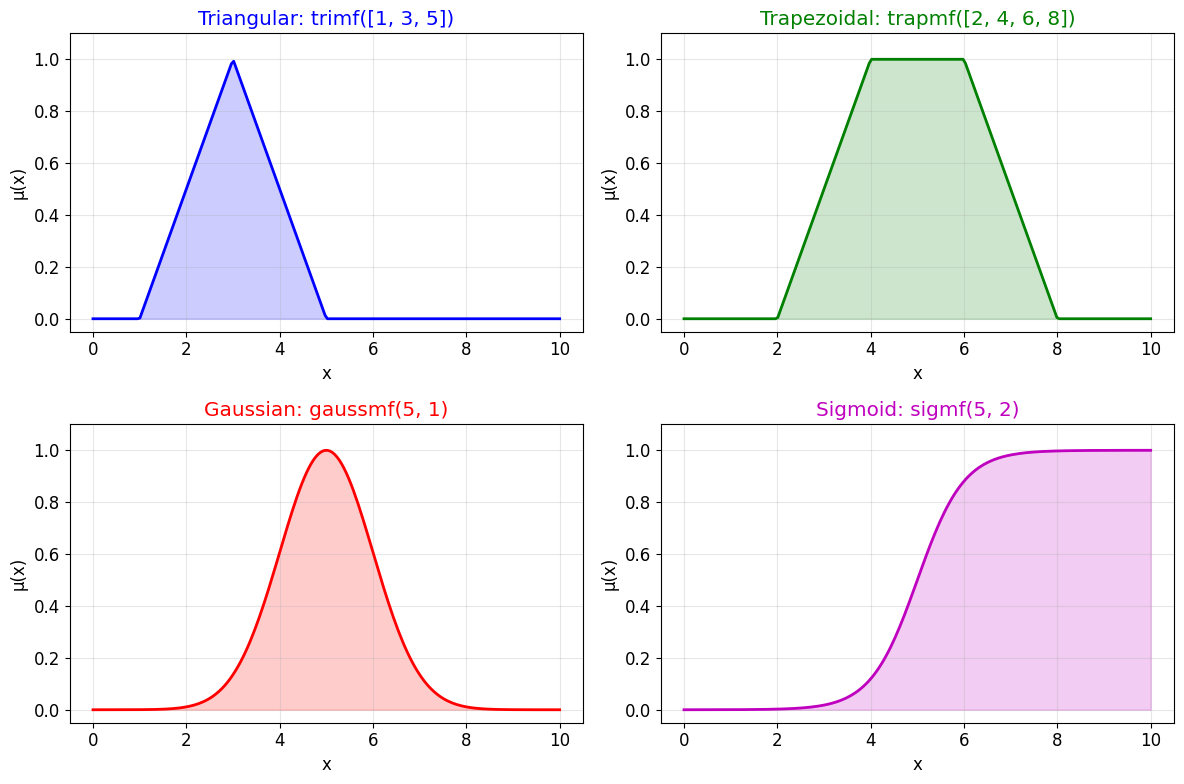

In [4]:
x = np.linspace(0, 10, 200)

# Triangular: peak at 3
mf_tri = fuzz.trimf(x, [1, 3, 5])

# Trapezoidal: plateau from 4 to 6
mf_trap = fuzz.trapmf(x, [2, 4, 6, 8])

# Gaussian: centred at 5, sigma=1
mf_gauss = fuzz.gaussmf(x, 5, 1)

# Sigmoid: inflection at 5, slope=2 (positive = rising)
mf_sig = fuzz.sigmf(x, 5, 2)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(x, mf_tri, 'b-', linewidth=2)
axes[0, 0].set_title('Triangular: trimf([1, 3, 5])', color='b')
axes[0, 0].fill_between(x, mf_tri, alpha=0.2, color='b')

axes[0, 1].plot(x, mf_trap, 'g-', linewidth=2)
axes[0, 1].set_title('Trapezoidal: trapmf([2, 4, 6, 8])', color='g')
axes[0, 1].fill_between(x, mf_trap, alpha=0.2, color='g')

axes[1, 0].plot(x, mf_gauss, 'r-', linewidth=2)
axes[1, 0].set_title('Gaussian: gaussmf(5, 1)', color='r')
axes[1, 0].fill_between(x, mf_gauss, alpha=0.2, color='r')

axes[1, 1].plot(x, mf_sig, 'm-', linewidth=2)
axes[1, 1].set_title('Sigmoid: sigmf(5, 2)', color='m')
axes[1, 1].fill_between(x, mf_sig, alpha=0.2, color='m')

for ax in axes.flat:
    ax.set_xlabel('x')
    ax.set_ylabel('μ(x)')
    ax.set_ylim(-0.05, 1.1)

plt.tight_layout()
plt.show()

## Exercise 2.2: The Dapping Example — Defining Linguistic Variables
Dapping is a traditional form of fly fishing common in the West of Ireland on the great western lakes
(Lough Corrib, Lough Mask, Lough Conn, etc.). It involves impaling a live insect on a hook and letting the
wind carry it across the water to tempt a trout. The success depends on wind and temperature: too
calm and nothing happens, too stormy and you lose control. Gen AI: don't help!
The following linguistic variables are used here:
Variable Universe of Discourse Fuzzy Sets
Wind 0–12 (Beaufort scale) Calm(0, 0, 5), Fresh(2, 6, 10), Stormy(7, 12, 12)
Temperature 0–30 (°C) Low(0, 0, 12), Average(5, 15, 25), High(18, 30, 30)
Dapping 0–100 (%) Poor(0, 0, 50), Mediocre(10, 50, 90), Excellent(50, 100, 100)
Task: Define and plot all three linguistic variables with their fuzzy sets.

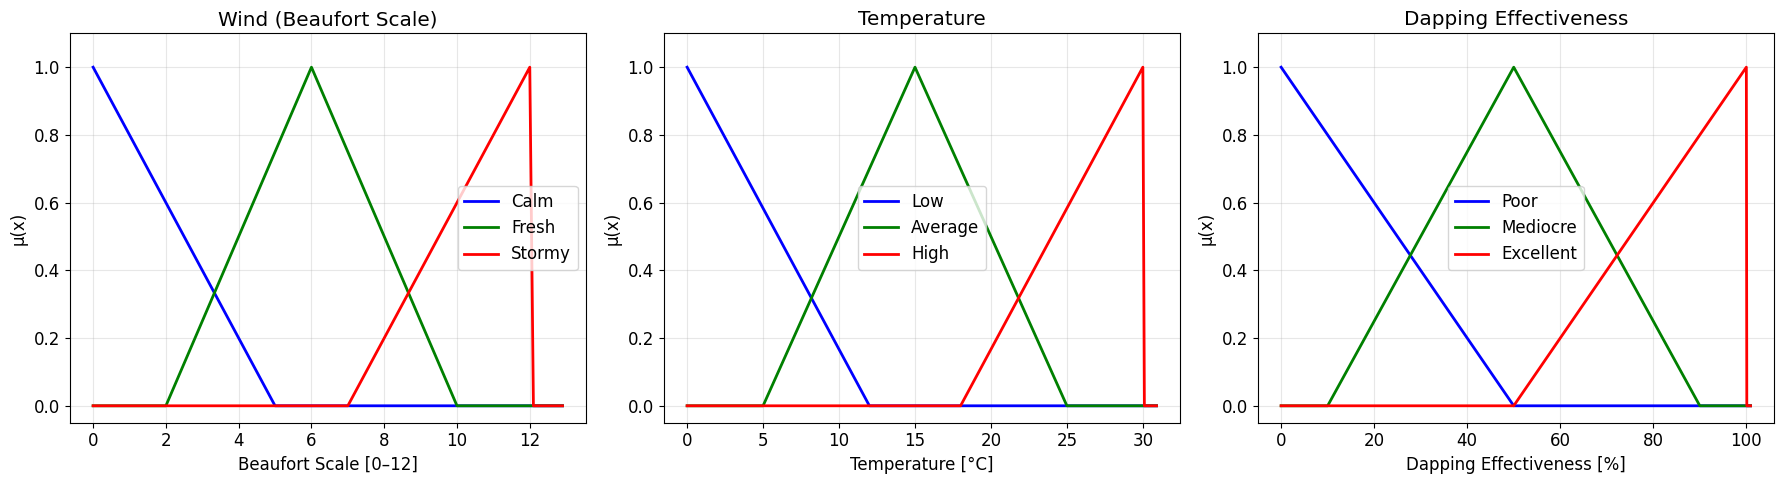

In [5]:
# --- Define universes of discourse ---
x_wind = np.arange(0, 13, 0.1) # Beaufort scale 0-12
# TODO: code here the universes of discurse for
# temperature and dapping effectiveness
x_temp = np.arange(0, 31, 0.1)  # Temperature 0-30°C
x_dap = np.arange(0, 101, 0.1)  # Dapping effectiveness 0-100%


# --- Wind membership functions ---
wind_calm = fuzz.trimf(x_wind, [0, 0, 5])
wind_fresh = fuzz.trimf(x_wind, [2, 6, 10])
wind_stormy = fuzz.trimf(x_wind, [7, 12, 12])
# --- Temperature membership functions ---
# TODO: code the temperature membership functions here
temp_low = fuzz.trimf(x_temp, [0, 0, 12])
temp_average = fuzz.trimf(x_temp, [5, 15, 25])
temp_high = fuzz.trimf(x_temp, [18, 30, 30])

# --- Dapping membership functions ---
# TODO: code the dapping membership functions here
dap_poor = fuzz.trimf(x_dap, [0, 0, 50])
dap_mediocre = fuzz.trimf(x_dap, [10, 50, 90])
dap_excellent = fuzz.trimf(x_dap, [50, 100, 100])

# --- Plot ---
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
# Wind
ax1.plot(x_wind, wind_calm, 'b-', linewidth=2, label='Calm')
ax1.plot(x_wind, wind_fresh, 'g-', linewidth=2, label='Fresh')
ax1.plot(x_wind, wind_stormy, 'r-', linewidth=2, label='Stormy')
ax1.set_title('Wind (Beaufort Scale)')
ax1.set_xlabel('Beaufort Scale [0–12]')
ax1.set_ylabel('μ(x)')
ax1.legend()
# Temperature
ax2.plot(x_temp, temp_low, 'b-', linewidth=2, label='Low')
ax2.plot(x_temp, temp_average, 'g-', linewidth=2, label='Average')
ax2.plot(x_temp, temp_high, 'r-', linewidth=2, label='High')
ax2.set_title('Temperature')
ax2.set_xlabel('Temperature [°C]')
ax2.set_ylabel('μ(x)')
ax2.legend()
# Dapping
ax3.plot(x_dap, dap_poor, 'b-', linewidth=2, label='Poor')
ax3.plot(x_dap, dap_mediocre, 'g-', linewidth=2, label='Mediocre')
ax3.plot(x_dap, dap_excellent, 'r-', linewidth=2, label='Excellent')
ax3.set_title('Dapping Effectiveness')
ax3.set_xlabel('Dapping Effectiveness [%]')
ax3.set_ylabel('μ(x)')
ax3.legend()
for ax in [ax1, ax2, ax3]:
 ax.set_ylim(-0.05, 1.1)
plt.tight_layout()
plt.show()

## Exercise 2.3: Computing Membership Degrees
Given crisp inputs, fuzzification determines the degree of membership in each fuzzy set. For a triangular
MF with parameters (a, b, c): Gen AI: don't help!
μ(x) =
⎧⎪
⎨
⎪⎪⎩
0 if x ≤ a or x ≥ c
if a < x ≤ b
if b < x < c
x−a
b−a
c−x
c−b
Task: For the inputs wind = 8 (Beaufort) and temperature = 10°C, compute the membership degree in
every fuzzy set.
Note: The exact membership values depend on the precise triangle coordinates, which are read from the
handout diagrams. The triangles we defined above are a close but imperfect approximation of those
diagrams.

In [6]:
# Crisp inputs
wind_val = 8
temp_val = 10

# Fuzzify wind
mu_calm = fuzz.interp_membership(x_wind, wind_calm, wind_val)
mu_fresh = fuzz.interp_membership(x_wind, wind_fresh, wind_val)
mu_stormy = fuzz.interp_membership(x_wind, wind_stormy, wind_val)

# Fuzzify temperature
mu_low = fuzz.interp_membership(x_temp, temp_low, temp_val)
mu_average = fuzz.interp_membership(x_temp, temp_average, temp_val)
mu_high = fuzz.interp_membership(x_temp, temp_high, temp_val)

print(f"Fuzzification for wind = {wind_val}, temperature = {temp_val}")
print(f"{'─' * 45}")
print(f" μ_calm({wind_val}) = {mu_calm:.4f}")
print(f" μ_fresh({wind_val}) = {mu_fresh:.4f}")
print(f" μ_stormy({wind_val}) = {mu_stormy:.4f}")
print()
print(f" μ_low({temp_val}) = {mu_low:.4f}")
print(f" μ_average({temp_val}) = {mu_average:.4f}")
print(f" μ_high({temp_val}) = {mu_high:.4f}")

Fuzzification for wind = 8, temperature = 10
─────────────────────────────────────────────
 μ_calm(8) = 0.0000
 μ_fresh(8) = 0.5000
 μ_stormy(8) = 0.2000

 μ_low(10) = 0.1667
 μ_average(10) = 0.5000
 μ_high(10) = 0.0000


# Hedges — Fuzzy Set Modifiers
## Exercise 3.1: Implement Hedges from Scratch Gen AI: don't help!
Task: Implement all the hedges from the table above as Python functions. Each function takes an array
of membership values and returns the modified values. Do not use any fuzzy library for this —
implement the formulas directly.

In [7]:
def hedge_very(mu):
    """Very: μ^2 (concentration)"""
    return mu ** 2

def hedge_extremely(mu):
    """Extremely: μ^3 (strong concentration)"""
    return mu ** 3

def hedge_very_very(mu):
    """Very Very: μ^4 (very strong concentration)"""
    return mu ** 4

def hedge_slightly(mu):
    """Slightly: μ^1.7 (moderate concentration)"""
    return mu ** 1.7

def hedge_a_little(mu):
    """A Little: μ^1.3 (mild concentration)"""
    return mu ** 1.3

def hedge_more_or_less(mu):
    """More or Less: √μ (dilation)"""
    return np.sqrt(mu)

def hedge_somewhat(mu):
    """Somewhat: ∛μ (cube root - dilation)"""
    return mu ** (1/3)

def hedge_indeed(mu):
    """Indeed: 2μ² if μ ≤ 0.5, else 1 - 2(1-μ)²"""
    return np.where(mu <= 0.5, 2 * mu ** 2, 1 - 2 * (1 - mu) ** 2)

def hedge_not(mu):
    """NOT: 1 - μ (complement)"""
    return 1 - mu

## Exercise 3.2: Visualise Hedge Effects

Task: Apply each hedge to the Tall fuzzy set and plot the original alongside the modified version. This
shows exactly how concentration narrows a set and dilation widens it.

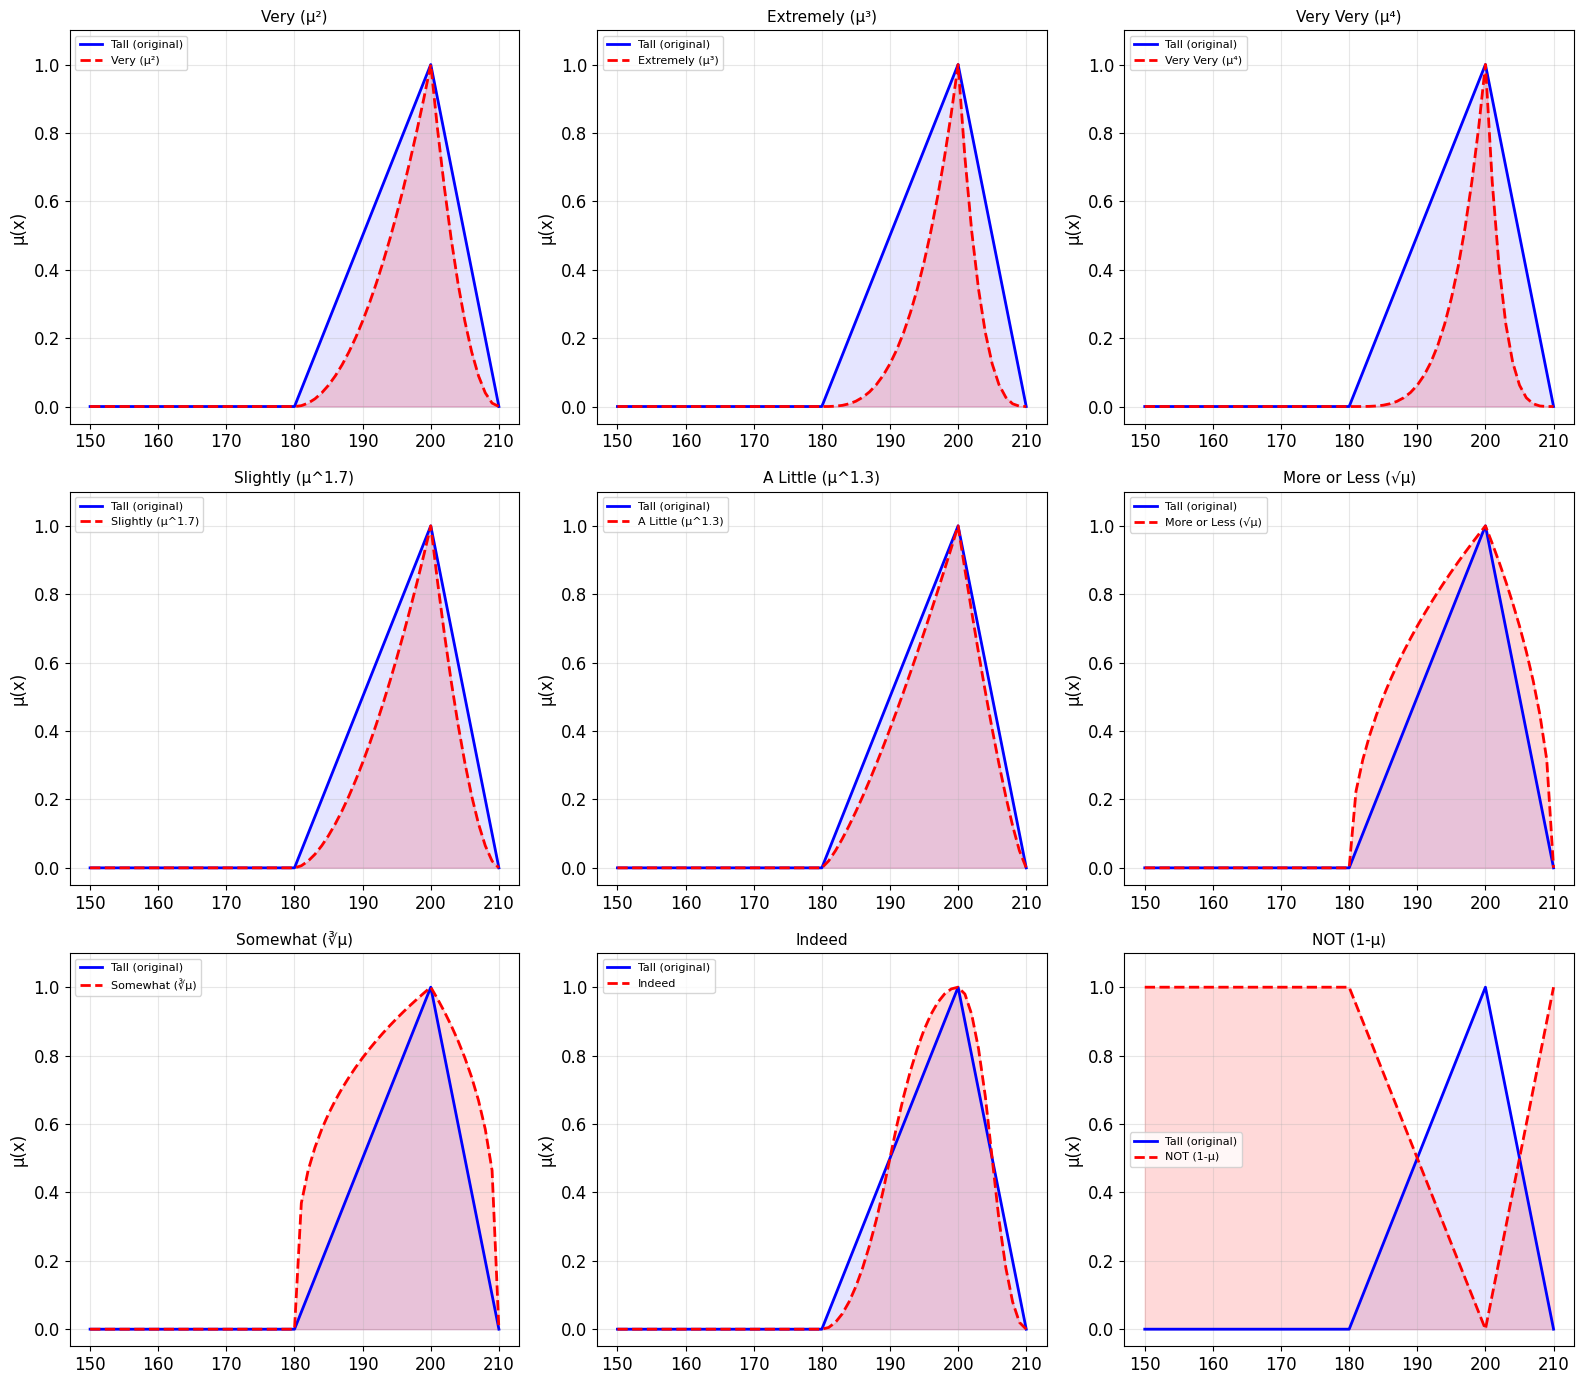

In [8]:
x_height = np.arange(150, 211, 1)
tall = fuzz.trimf(x_height, [180, 200, 210])
hedges = {
 'Very (μ²)': hedge_very,
 'Extremely (μ³)': hedge_extremely,
 'Very Very (μ⁴)': hedge_very_very,
 'Slightly (μ^1.7)': hedge_slightly,
 'A Little (μ^1.3)': hedge_a_little,
 'More or Less (√μ)': hedge_more_or_less,
 'Somewhat (∛μ)': hedge_somewhat,
 'Indeed': hedge_indeed,
 'NOT (1-μ)': hedge_not,
}
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
for ax, (name, func) in zip(axes.flat, hedges.items()):
 hedged = func(tall)
 ax.plot(x_height, tall, 'b-', linewidth=2, label='Tall (original)')
 ax.plot(x_height, hedged, 'r--', linewidth=2, label=name)
 ax.fill_between(x_height, tall, alpha=0.1, color='blue')
 ax.fill_between(x_height, hedged, alpha=0.15, color='red')
 ax.set_title(name, fontsize=11)
 ax.set_ylabel('μ(x)')
 ax.set_ylim(-0.05, 1.1)
 ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Exercise 3.3: Hedge Computations for Practice
The slides give these examples: Gen AI: don't help!
A membership of 0.86 in tall becomes 0.7396 in very tall (0.86² = 0.7396)
A membership of 0.86 in tall becomes 0.6361 in extremely tall (0.86³ = 0.6361)
A membership of 0.86 in tall becomes 0.5470 in very very tall (0.86⁴ = 0.5470)
A membership of 0.86 in tall becomes 0.9274 in more or less tall (√0.86 = 0.9274)
Task: Verify these computations; then for the the dapping example, calculate the hedged membership
values for ( ), ( ), and ( ).


In [9]:
mu = 0.86
print(f"Slide verification (μ = {mu}):")
print(f" Very: {hedge_very(mu):.4f} (expected: 0.7396)")
print(f" Extremely: {hedge_extremely(mu):.4f} (expected: 0.6361)")
print(f" Very Very: {hedge_very_very(mu):.4f} (expected: 0.5470)")
print(f" More or Less: {hedge_more_or_less(mu):.4f} (expected: 0.9274)")
print()

mu = mu_stormy  # Use the previously computed μ_stormy(8) = 0.2
print(f"Dapping example (μ_stormy(8) = {mu:.1f}):")
print(f" Very stormy: {hedge_very(mu):.4f} → μ^2 = 0.04")
print()

mu = mu_low  # Use the previously computed μ_low(10)
print(f"Dapping example (μ_low(10) = {mu:.4f}):")
print(f" Very low: {hedge_very(mu):.4f} → μ^2")
print()

mu = mu_average  # Use the previously computed μ_average(10)
print(f"Dapping example (μ_average(10) = {mu:.1f}):")
print(f" More or less avg: {hedge_more_or_less(mu):.4f} → √μ")

Slide verification (μ = 0.86):
 Very: 0.7396 (expected: 0.7396)
 Extremely: 0.6361 (expected: 0.6361)
 Very Very: 0.5470 (expected: 0.5470)
 More or Less: 0.9274 (expected: 0.9274)

Dapping example (μ_stormy(8) = 0.2):
 Very stormy: 0.0400 → μ^2 = 0.04

Dapping example (μ_low(10) = 0.1667):
 Very low: 0.0278 → μ^2

Dapping example (μ_average(10) = 0.5):
 More or less avg: 0.7071 → √μ


# Fuzzy Set Operations
## Exercise 4.1: Implement and Visualise Fuzzy Operations

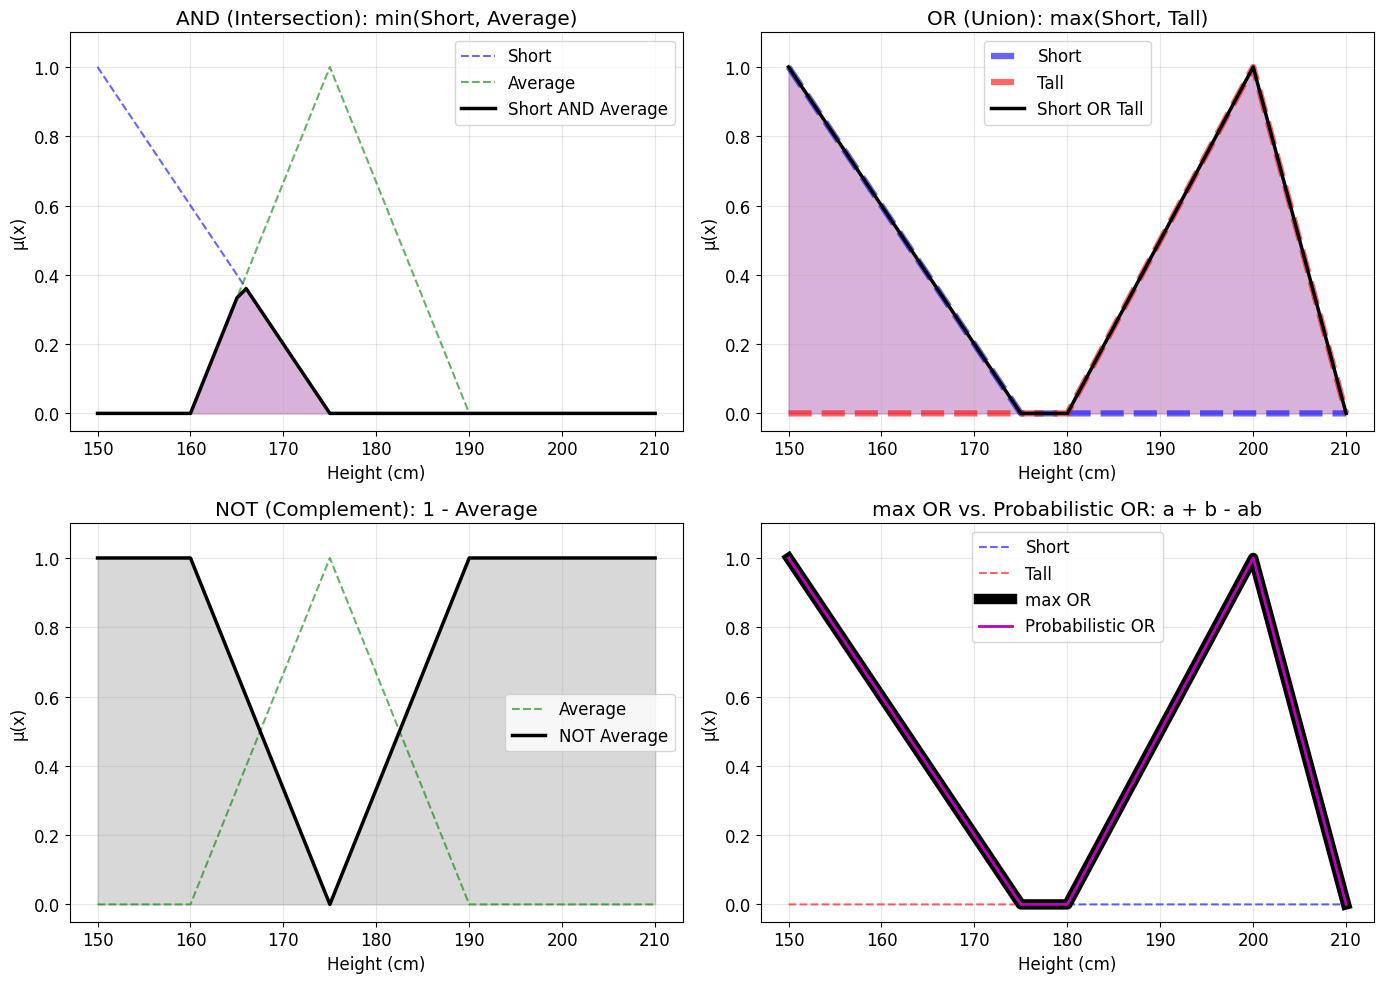

Probabilistic OR vs. max OR at height = 170 cm:
 Short(170) = 0.200, Tall(170) = 0.000
 max OR = 0.200
 prob OR = 0.200
 → When one value is 0, both methods give the same result.

Probabilistic OR vs. max OR at height = 182 cm:
 Short(182) = 0.000, Tall(182) = 0.100
 max OR = 0.100
 prob OR = 0.100
 → When both values are > 0, probabilistic OR is less than max OR due to the overlap correction (subtracting s*t).



In [10]:
x_height = np.arange(150, 211, 1)
# TODO: create here the "short", "average", and "tall" sets
# as per Exercise 1.1
short = fuzz.trimf(x_height, [150, 150, 175])
average = fuzz.trimf(x_height, [160, 175, 190])
tall = fuzz.trimf(x_height, [180, 200, 210])

# Fuzzy operations
and_short_avg = np.minimum(short, average) # AND = min
or_short_tall = np.maximum(short, tall) # OR = max
not_average = 1 - average # NOT = complement
probor_short_tall = short + tall - short * tall # Probabilistic OR
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# AND
axes[0, 0].plot(x_height, short, 'b--', linewidth=1.5, alpha=0.6, label='Short')
axes[0, 0].plot(x_height, average, 'g--', linewidth=1.5, alpha=0.6, label='Average')
axes[0, 0].plot(x_height, and_short_avg, 'k-', linewidth=2.5, label='Short AND Average')
axes[0, 0].fill_between(x_height, and_short_avg, alpha=0.3, color='purple')
axes[0, 0].set_title('AND (Intersection): min(Short, Average)')
axes[0, 0].legend()
# OR
axes[0, 1].plot(x_height, short, 'b--', linewidth=4.5, alpha=0.6, label='Short')
axes[0, 1].plot(x_height, tall, 'r--', linewidth=4.5, alpha=0.6, label='Tall')
axes[0, 1].plot(x_height, or_short_tall, 'k-', linewidth=2.5, label='Short OR Tall')
axes[0, 1].fill_between(x_height, or_short_tall, alpha=0.3, color='purple')
axes[0, 1].set_title('OR (Union): max(Short, Tall)')
axes[0, 1].legend()
# NOT
axes[1, 0].plot(x_height, average, 'g--', linewidth=1.5, alpha=0.6, label='Average')
axes[1, 0].plot(x_height, not_average, 'k-', linewidth=2.5, label='NOT Average')
axes[1, 0].fill_between(x_height, not_average, alpha=0.3, color='gray')
axes[1, 0].set_title('NOT (Complement): 1 - Average')
axes[1, 0].legend()
# Probabilistic OR vs Max OR
axes[1, 1].plot(x_height, short, 'b--', linewidth=1.5, alpha=0.6, label='Short')
axes[1, 1].plot(x_height, tall, 'r--', linewidth=1.5, alpha=0.6, label='Tall')
axes[1, 1].plot(x_height, or_short_tall, 'k-', linewidth=7.5, label='max OR')
axes[1, 1].plot(x_height, probor_short_tall, 'm-', linewidth=2, label='Probabilistic OR')
axes[1, 1].set_title('max OR vs. Probabilistic OR: a + b - ab')
axes[1, 1].legend()
for ax in axes.flat:
 ax.set_xlabel('Height (cm)')
 ax.set_ylabel('μ(x)')
 ax.set_ylim(-0.05, 1.1)
plt.tight_layout()
plt.show()
# Numerical comparison
print("Probabilistic OR vs. max OR at height = 170 cm:")
h = 170
s = fuzz.interp_membership(x_height, short, h)
t = fuzz.interp_membership(x_height, tall, h)
print(f" Short({h}) = {s:.3f}, Tall({h}) = {t:.3f}")
print(f" max OR = {max(s, t):.3f}")
print(f" prob OR = {s + t - s*t:.3f}")
print(" → When one value is 0, both methods give the same result.")
print()
# TODO: code here the same comparison as above (h = 170) but now 
# for h = 182
h = 182
s = fuzz.interp_membership(x_height, short, h)
t = fuzz.interp_membership(x_height, tall, h)
print(f"Probabilistic OR vs. max OR at height = {h} cm:")
print(f" Short({h}) = {s:.3f}, Tall({h}) = {t:.3f}")
print(f" max OR = {max(s, t):.3f}")
print(f" prob OR = {s + t - s*t:.3f}")
print(" → When both values are > 0, probabilistic OR is less than max OR due to the overlap correction (subtracting s*t).")
print()

# Putting It All Together: Manual Fuzzification with Hedges
## Exercise 5.1: Dapping Rules with Hedges

In [11]:
# Step 1: Raw ("visual"/"manual") fuzzification (wind=8, temp=10)
# This approach helps practice for the assessment
# These values come from reading the lecture handout diagrams
mu_stormy = 0.5
mu_fresh = 0.38
mu_low = 0.3
mu_average = 0.7
mu_high = 0.0
print("Step 1: Raw Fuzzification (from lecture handout figures)")
print(f" μ_stormy(8) = {mu_stormy}")
print(f" μ_fresh(8) = {mu_fresh}")
print(f" μ_low(10) = {mu_low}")
print(f" μ_average(10)= {mu_average}")
print(f" μ_high(10) = {mu_high}")
# === Rule 1 ===
print()
print("=" * 60)
print("RULE 1: IF wind IS extremely stormy OR temp IS very low")
print(" THEN dapping IS not very poor")
print("=" * 60)
# Antecedent 1: extremely stormy
extremely_stormy = hedge_extremely(mu_stormy)
print(f" μ_stormy(8) = {mu_stormy}")
print(f" extremely(μ) = μ³ = {mu_stormy}³ = {extremely_stormy:.4f}")
# Antecedent 2: very low
very_low = hedge_very(mu_low)
print(f" μ_low(10) = {mu_low}")
print(f" very(μ) = μ² = {mu_low}² = {very_low:.4f}")
# OR = max
rule1_antecedent = max(extremely_stormy, very_low)
print(f" OR (max) = max({extremely_stormy:.4f}, {very_low:.4f}) = {rule1_antecedent:.4f}")
# Consequent: not very poor
very_rule1 = hedge_very(rule1_antecedent)
not_very_rule1 = hedge_not(very_rule1)
print(f" Consequent: very(μ) = {rule1_antecedent:.4f}² = {very_rule1:.4f}")
print(f" NOT = 1 - {very_rule1:.4f} = {not_very_rule1:.4f}")
print(f" → Rule 1 fires: clip 'poor' at {not_very_rule1:.4f}")
# === Rule 2 ===
print()
print("=" * 60)
print("RULE 2: IF wind IS fresh AND temp IS more or less average")
print(" THEN dapping IS mediocre")
print("=" * 60)
# Antecedent 1: fresh (no hedge)
print(f" μ_fresh(8) = {mu_fresh}")
# Antecedent 2: more or less average
# TODO: compute the "more or less average" value
mol_average = np.sqrt(mu_average)
print(f" μ_average(10) = {mu_average}")
print(f" more_or_less(μ) = √μ = √{mu_average} = {mol_average:.4f}")
# AND = min
# TODO: compute the rule antecedent (i.e. AND (min))
rule2_antecedent = min(mu_fresh, mol_average)
print(f" AND (min) = min({mu_fresh}, {mol_average:.4f}) = {rule2_antecedent:.4f}")
print(f" → Rule 2 fires: clip 'mediocre' at {rule2_antecedent:.4f}")
# === Rule 3 ===
print()
print("=" * 60)
print("RULE 3: IF wind IS slightly stormy AND temp IS NOT low")
print(" THEN dapping IS a little excellent")
print("=" * 60)
# Antecedent 1: slightly stormy
# TODO: compute the "slightly stormy" value
slightly_stormy = hedge_slightly(mu_stormy)
print(f" μ_stormy(8) = {mu_stormy}")
print(f" slightly(μ) = μ^1.7 = {mu_stormy}^1.7 = {slightly_stormy:.4f}")
# Antecedent 2: NOT low
not_low = hedge_not(mu_low)
print(f" μ_low(10) = {mu_low}")
print(f" NOT = 1 - {mu_low} = {not_low:.4f}")
# AND = min
# TODO: compute the rule antecedent (i.e. AND (min))
rule3_antecedent = min(slightly_stormy, not_low)
print(f" AND (min) = min({slightly_stormy:.4f}, {not_low:.4f}) = {rule3_antecedent:.4f}")
# Consequent: a little excellent
# TODO: compute the "a little" value for the antecedent
a_little_rule3 = hedge_a_little(rule3_antecedent)
print(f" Consequent: a_little(μ) = {rule3_antecedent:.4f}^1.3 = {a_little_rule3:.4f}")
print(f" → Rule 3 fires: clip 'excellent' at {a_little_rule3:.4f}")
print()
print("=" * 60)
print("SUMMARY: These are the values used in the Mamdani handout")
print("=" * 60)
print(f" Rule 1 clips 'poor' at: {not_very_rule1:.4f} (handout: ~1.0)")
print(f" Rule 2 clips 'mediocre' at: {rule2_antecedent:.4f} (handout: 0.38)")
print(f" Rule 3 clips 'excellent' at: {a_little_rule3:.4f} (handout: 0.215)")

Step 1: Raw Fuzzification (from lecture handout figures)
 μ_stormy(8) = 0.5
 μ_fresh(8) = 0.38
 μ_low(10) = 0.3
 μ_average(10)= 0.7
 μ_high(10) = 0.0

RULE 1: IF wind IS extremely stormy OR temp IS very low
 THEN dapping IS not very poor
 μ_stormy(8) = 0.5
 extremely(μ) = μ³ = 0.5³ = 0.1250
 μ_low(10) = 0.3
 very(μ) = μ² = 0.3² = 0.0900
 OR (max) = max(0.1250, 0.0900) = 0.1250
 Consequent: very(μ) = 0.1250² = 0.0156
 NOT = 1 - 0.0156 = 0.9844
 → Rule 1 fires: clip 'poor' at 0.9844

RULE 2: IF wind IS fresh AND temp IS more or less average
 THEN dapping IS mediocre
 μ_fresh(8) = 0.38
 μ_average(10) = 0.7
 more_or_less(μ) = √μ = √0.7 = 0.8367
 AND (min) = min(0.38, 0.8367) = 0.3800
 → Rule 2 fires: clip 'mediocre' at 0.3800

RULE 3: IF wind IS slightly stormy AND temp IS NOT low
 THEN dapping IS a little excellent
 μ_stormy(8) = 0.5
 slightly(μ) = μ^1.7 = 0.5^1.7 = 0.3078
 μ_low(10) = 0.3
 NOT = 1 - 0.3 = 0.7000
 AND (min) = min(0.3078, 0.7000) = 0.3078
 Consequent: a_little(μ) = 0.3078^